In [1]:
!pip install imbalanced-learn matplotlib seaborn

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("poster")

In [3]:
from sklearn.datasets import make_classification

def create_dataset(
    n_samples=1000,
    weights=(0.01, 0.01, 0.98),
    n_classes=3,
    class_sep=0.8,
    n_clusters=1,
):
    return make_classification(
        n_samples=n_samples,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_repeated=0,
        n_classes=n_classes,
        n_clusters_per_class=n_clusters,
        weights=list(weights),
        class_sep=class_sep,
        random_state=0,
    )

In [4]:
import numpy as np
from matplotlib import cm
import matplotlib.colors as mcolors

colors_1 = ['#1b9e77', '#d95f02', '#7570b3']
cmap_1 = mcolors.LinearSegmentedColormap.from_list('custom_cmap_1', colors_1, N=3)

colors_2 = ['#7fc97f', '#beaed4', '#fdc086']
cmap_2 = mcolors.LinearSegmentedColormap.from_list('custom_cmap_2', colors_2, N=3)

colors_3 = ['#ff0000', '#00ff00', '#0000ff']
cmap_3 = mcolors.LinearSegmentedColormap.from_list('custom_cmap_3', colors_3, N=3)

In [5]:
def plot_resampling(X, y, sampler, ax, cmap=cmap_3, title=None):
    X_res, y_res = sampler.fit_resample(X, y)
    ax.scatter(X_res[:, 0], X_res[:, 1], c=y_res, alpha=0.8, edgecolor="k", cmap=cmap)
    if title is None:
        title = f"Resampling with {sampler.__class__.__name__}"
    ax.set_title(title)
    sns.despine(ax=ax, offset=10)

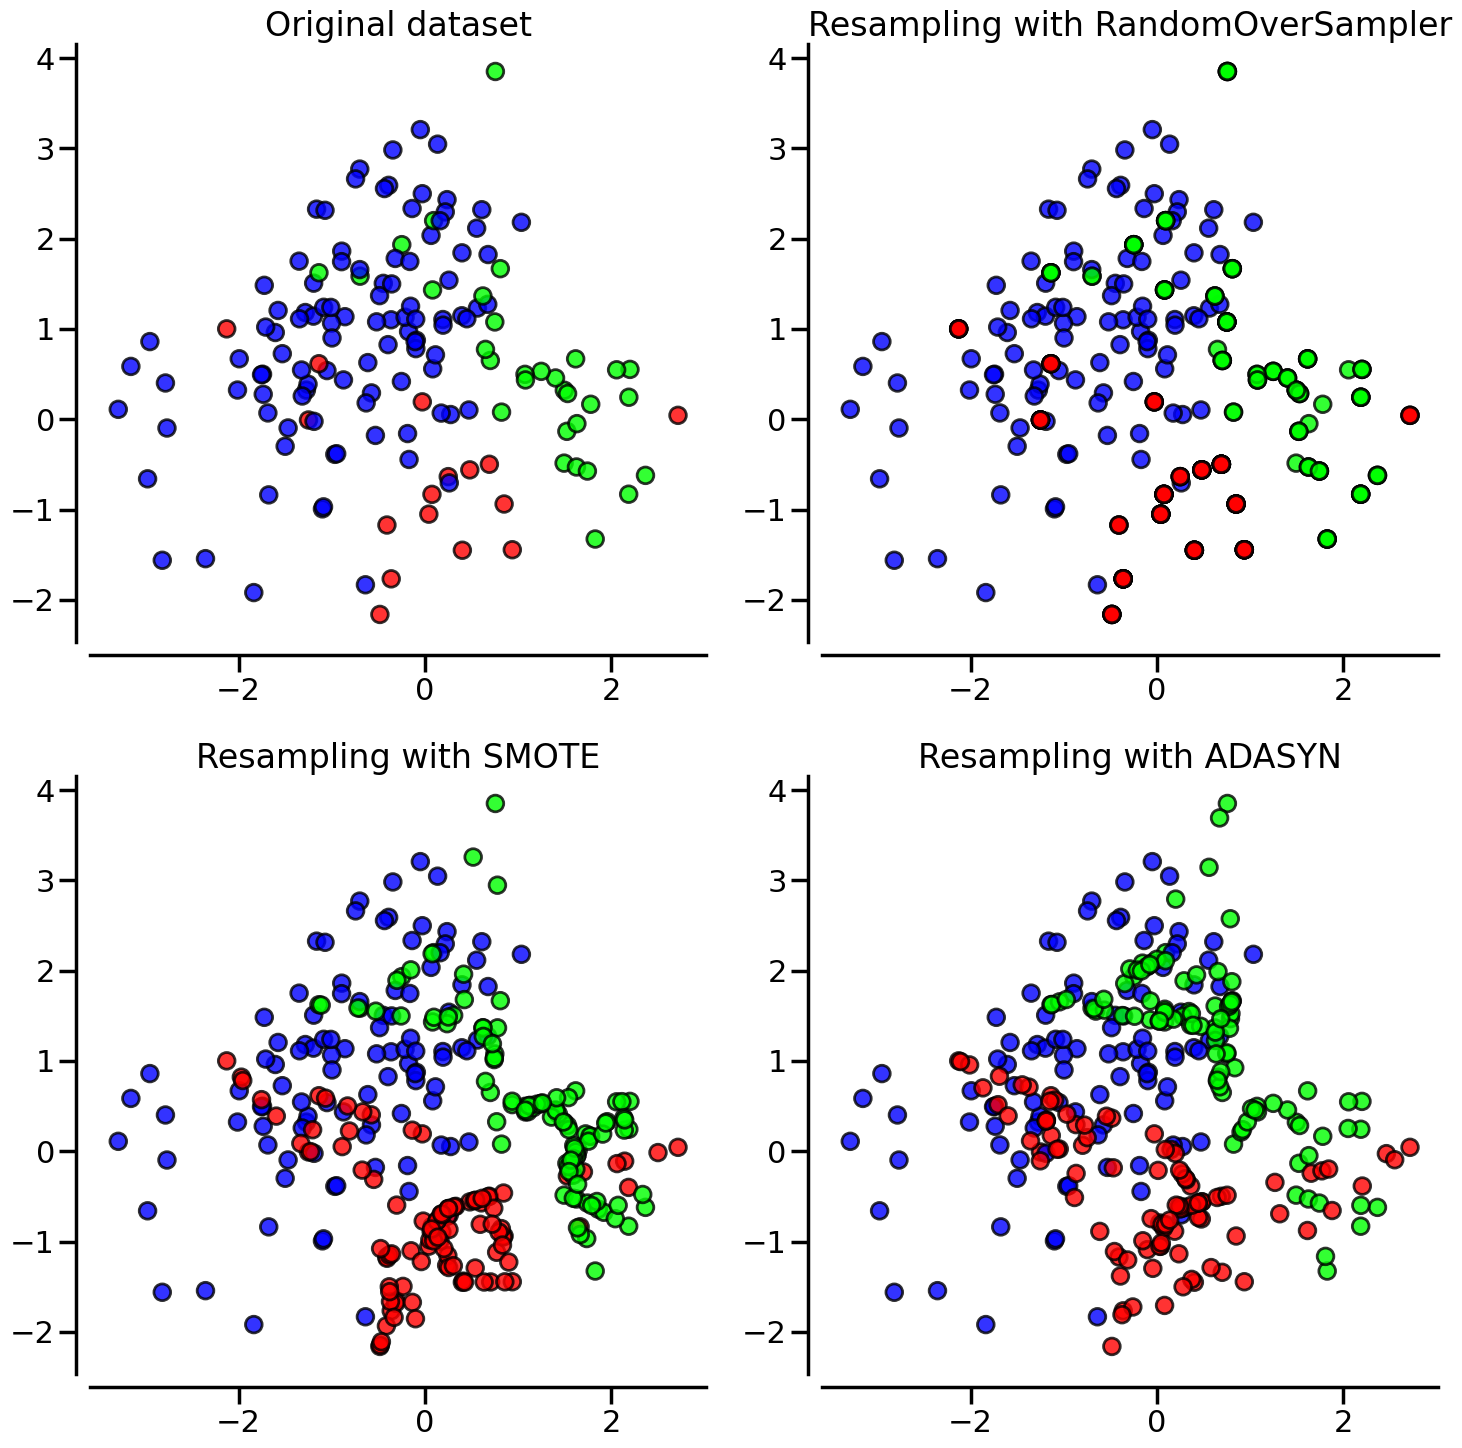

In [6]:
import matplotlib.pyplot as plt
from imblearn import FunctionSampler  # to use a idendity sampler
from imblearn.over_sampling import ADASYN, SMOTE, RandomOverSampler

X, y = create_dataset(n_samples=150, weights=(0.1, 0.2, 0.7))

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))

samplers = [
    FunctionSampler(),
    RandomOverSampler(random_state=0),
    SMOTE(random_state=0),
    ADASYN(random_state=0),
]

for ax, sampler in zip(axs.ravel(), samplers):
    title = "Original dataset" if isinstance(sampler, FunctionSampler) else None
    plot_resampling(X, y, sampler, ax, title=title)
fig.tight_layout()
fig.savefig('resampling_plot.png', dpi=300)  # You can change the file name and format as needed